In [2]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import pandas as pd
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import *
from laboneq.analysis.fitting import oscillatory
from laboneq.analysis.fitting import oscillatory_decay

print(laboneq.__version__)

2.54.0


In [ ]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.09.24 17:57:35.148] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/yizheng/Downloads/Qubit_measurement/laboneq_output/log
[2025.09.24 17:57:35.150] INFO    VERSION: laboneq 2.54.0
[2025.09.24 17:57:35.151] INFO    Connecting to data server at 127.0.0.1:8004
[2025.09.24 17:57:35.153] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.1.17 at 127.0.0.1:8004
[2025.09.24 17:57:35.155] INFO    Configuring the device setup
[2025.09.24 17:57:35.157] INFO    The device setup is configured


In [50]:
res_lo_freq = 7e9
qb_lo_freq = 5.2e9
qubit_label = "Q3"  # change if needed
# qb_freq = 5.23809e9 #Q1
# qb_freq = 5.147960e9 #Q2
qb_freq = 5.176650e9 #Q3


# res_freq = 6.77788288e9 #Q1
# res_freq = 6.80982122e9 #Q2
res_freq = 6.84365284e9 #Q3
rlx_time = 50e-6

delay_start = 1e-8
delay_stop = 50e-6
delay_num = 201


# drive_pulse_amp = 0.305 #Q1
# drive_pulse_amp = 0.449 #Q2
drive_pulse_amp = 0.721 #Q3
# drive_pulse_amp = 0.184 #Q4
# drive_pulse_amp = 0.263 #Q5
# drive_pulse_amp =  0.188#Q6

# drive_pulse_length = 1.373e-6 # Q1
# drive_pulse_length = 2.716e-6 # Q2
drive_pulse_length = 0.411e-6 # Q3
# drive_pulse_length = 0.974e-6 # Q4
# drive_pulse_length = 0.979e-6 # Q5
# drive_pulse_length =  1.034e-6# Q6

drive_range = -10
# drive_range = 0
num_averages = 12  # average number = 2^n, n_max = 17
measure_range = -30  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.2
measure_pulse_length = 5e-6
acquire_range = -45

In [51]:
def create_delay_sweep(
    start=delay_start, stop=delay_stop, count=delay_num):
    time_sweep = LinearSweepParameter(
        uid="time_sweep_param", start=start, stop=stop, count=count)
    return time_sweep

In [52]:
# function that returns an amplitude Rabi experiment
readout_pulse = pulse_library.const(uid="readout_pulse",length = measure_pulse_length,amplitude=measure_amp, can_compress=False)
drive_pulse = pulse_library.const(uid="drive", length=drive_pulse_length/2, amplitude=drive_pulse_amp, can_compress=False)

def ramsey( time_sweep):
    exp_ramsey = Experiment(
        uid="Ramsey Experiment",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )
    
    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_ramsey.acquire_loop_rt(
        uid="ramsey_shots",
        count=2**num_averages,
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        # inner loop - real time sweep of Ramsey time delays
        with exp_ramsey.sweep(
            uid="ramsey_sweep", parameter=time_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_ramsey.section(
                uid="qubit_excitation"):
                exp_ramsey.play(signal="drive", pulse=drive_pulse)
                exp_ramsey.delay(signal="drive", time=time_sweep)
                exp_ramsey.play(signal="drive", pulse=drive_pulse)
            # readout pulse and data acquisition
            with exp_ramsey.section(
                uid="readout_section", play_after="qubit_excitation"
            ):
                # play readout pulse on measure line
                # exp_ramsey.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                # exp_ramsey.acquire(
                #     signal="acquire",
                #     handle="ramsey",
                #     kernel=readout_pulse,
                # )
                exp_ramsey.measure(
                    measure_signal='measure',
                    measure_pulse=readout_pulse,
                    acquire_signal="acquire",
                    integration_length = measure_pulse_length,
                    handle="ramsey",
                    reset_delay = 50e-6,
                )

            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_ramsey.section(uid="relax", length=rlx_time):
                exp_ramsey.reserve(signal="measure")
                exp_ramsey.reserve(signal = "acquire")
    return exp_ramsey

In [53]:
# define pulses and create experiment
time_sweep = create_delay_sweep(delay_start, delay_stop, delay_num)

ramsey_exp = ramsey(time_sweep=time_sweep)

#  signal map for qubit
def signal_map_default():
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map
ramsey_exp.set_signal_map(signal_map_default())

In [54]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq -qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
ramsey_exp.set_calibration(exp_calibration)

In [55]:
# compile the experiment on the open instrument session
compiled_ramsey = session.compile(ramsey_exp)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Ramsey", compiled_ramsey)

[2025.09.20 23:49:32.036] INFO    Starting LabOne Q Compiler run...
[2025.09.20 23:49:32.560] INFO    Schedule completed. [0.525 s]
[2025.09.20 23:49:32.719] INFO    Code generation completed for all AWGs. [0.150 s]
[2025.09.20 23:49:32.719] INFO    Completed compilation step 1 of 1. [0.677 s]
[2025.09.20 23:49:32.723] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.09.20 23:49:32.723] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.09.20 23:49:32.723] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.09.20 23:49:32.723] INFO      device_shfqc        0        809            0           1     20000  
[2025.09.20 23:49:32.723] INFO      device_shfqc_sg     1        857           17          16     13632  
[2025.09.20 23:49:32.723] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.09.20 23:49:32.723] INFO      TOTAL                       1666 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Ramsey_2025-09-20-23-49-32.html

In [56]:
#plot_simulation(compiled_ramsey, start_time=300e-6, length=5e-6)

In [57]:
# run the compiled experiemnt
ramsey_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")

# --- Make output folder + timestamp ---
outdir = "Ramsey(T2)_results"
os.makedirs(outdir, exist_ok=True)

[2025.09.20 23:49:33.326] INFO    Starting near-time execution...
[2025.09.20 23:49:33.404] INFO    Estimated RT execution time: 107.37 s.
[2025.09.20 23:51:20.864] INFO    Finished near-time execution.


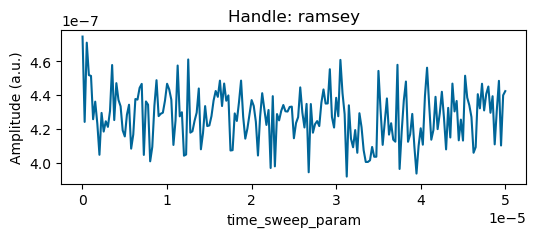

In [58]:
# plot_result_2d(ramsey_results, list(ramsey_results.acquired_results.keys())[0])
plot_results(ramsey_results)

Saved figure to Ramsey(T2)_results\T2_Ramsey_Q3_20250920T235120.png
Saved data to Ramsey(T2)_results\T2_Ramsey_Q3_20250920T235120.csv


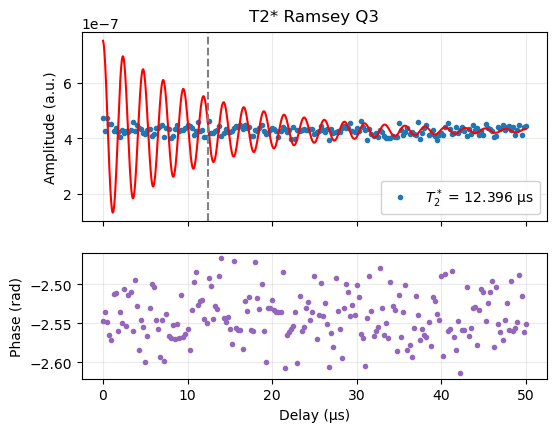

In [59]:
# Pull Ramsey data
ramsey_res   = ramsey_results.get_data("ramsey")      # complex data (IQ)
ramsey_delay = ramsey_results.get_axis("ramsey")[0]   # seconds

# Convert to μs for plotting and fitting
x = 1e6 * np.asarray(ramsey_delay, float)             # μs
I = np.asarray(np.real(ramsey_res), float)
Q = np.asarray(np.imag(ramsey_res), float)
mag = np.abs(ramsey_res).astype(float)
phase_rad = np.angle(ramsey_res)

# Clean + sort
m = np.isfinite(x) & np.isfinite(I) & np.isfinite(Q) & np.isfinite(mag) & np.isfinite(phase_rad)
x, I, Q, mag, phase_rad = x[m], I[m], Q[m], mag[m], phase_rad[m]
idx = np.argsort(x)
x, I, Q, mag, phase_rad = x[idx], I[idx], Q[idx], mag[idx], phase_rad[idx]

# ---------- Choose the quadrature to fit ----------
# (kept for compatibility, but we will FIT ONLY ON MAGNITUDE below)
def _detrend(y):
    # simple linear detrend
    A = np.vstack([x, np.ones_like(x)]).T
    c1, c0 = np.linalg.lstsq(A, y, rcond=None)[0]
    return y - (c1*x + c0)

I_dt = _detrend(I)
Q_dt = _detrend(Q)
use_I = np.nanstd(I_dt) >= np.nanstd(Q_dt)
y = I if use_I else Q
fit_label = "I" if use_I else "Q"

# ---------- Initial frequency guess via FFT (now based on MAGNITUDE) ----------
# x in μs -> frequency in cycles/μs (i.e., MHz)
xspan = x.max() - x.min()
if xspan <= 0:
    raise RuntimeError("Ramsey time axis has zero span; cannot fit.")

n_fft = 4096
x_uni = np.linspace(x.min(), x.max(), n_fft)
# detrend magnitude for cleaner spectral peak
mag_dt = _detrend(mag)
mag_uni = np.interp(x_uni, x, mag_dt)
w = np.hanning(n_fft)
yf = np.fft.rfft(mag_uni * w)
ff = np.fft.rfftfreq(n_fft, d=(x_uni[1]-x_uni[0]))  # cycles per μs (MHz)
# ignore DC
pk = np.argmax(np.abs(yf[1:])) + 1
f0_MHz_guess = float(ff[pk]) if ff[pk] > 0 else 0.05  # MHz

# ---------- T2* model (fit in μs, freq in MHz) ----------
def T2_ramsey_model(t_us, A, T2star_us, fdet_MHz, phi, C):
    return A * np.exp(-t_us / T2star_us) * np.cos(2.0*np.pi * fdet_MHz * t_us + phi) + C

# Initial guesses & bounds (now from MAGNITUDE)
A_guess  = 0.5 * (np.nanmax(mag) - np.nanmin(mag))
C_guess  = float(np.nanmedian(mag))
T2_guess = max(np.median(x), 1e-3)  # μs; avoid zero
phi_guess = 0.0

p0 = [max(A_guess, 1e-6), T2_guess, max(f0_MHz_guess, 1e-4), phi_guess, C_guess]
bounds = (
    [0.0,      1e-6,     0.0,        -2*np.pi, -np.inf],   # lower
    [np.inf,   np.inf,   np.inf,      2*np.pi,  np.inf],    # upper
)

# ---------- Fit ON MAGNITUDE ----------
from scipy.optimize import curve_fit

popt, pcov = curve_fit(
    T2_ramsey_model, x, mag,
    p0=p0, bounds=bounds, maxfev=20000
)
A_fit, T2star_fit_us, fdet_fit_MHz, phi_fit, C_fit = popt

# Smooth curve for display
xf = np.linspace(x.min(), x.max(), 1200)
y_fit = T2_ramsey_model(xf, *popt)

# ---------- Plot: show positive magnitude on top (fit is unchanged) ----------
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                        gridspec_kw={'height_ratios': [1.5, 1.0]})

# Top: magnitude (always >= 0), looks like your "correct" reference plot
axs[0].plot(x, mag, 'o', ms=3, label="|IQ| (a.u.)")
axs[0].plot(xf, y_fit, '-r', lw=1.5, label="fit on |IQ|")
axs[0].axvline(T2star_fit_us, color="grey", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Amplitude (a.u.)")
axs[0].legend(
    [rf"$T_2^*$ = {T2star_fit_us:.3f} μs"],
    loc="lower right", framealpha=0.9
)
axs[0].set_title(f"T2* Ramsey {qubit_label}", fontsize=12, pad=8)
axs[0].grid(True, alpha=0.25)

# Bottom: phase vs time (unwrapped) for completeness
phase_unw = np.unwrap(phase_rad)
axs[1].plot(x, phase_unw, 'o', ms=3, color="tab:purple")
axs[1].set_xlabel("Delay (μs)")
axs[1].set_ylabel("Phase (rad)")
axs[1].grid(True, alpha=0.25)

# ---------- Save figure ----------
fig_path = os.path.join(outdir, f"T2_Ramsey_{qubit_label}_{timestamp}.png")
plt.savefig(fig_path, dpi=600)
print(f"Saved figure to {fig_path}")

# ---------- Save CSV ----------
df = pd.DataFrame({
    "Delay_us": x,
    "I": I,
    "Q": Q,
    "Magnitude_linear": mag,
    "Phase_rad": phase_rad,
    "Fit_channel": np.full_like(x, "MAG", dtype=object),  # reflect magnitude-only fit
    "Fit_on_data": T2_ramsey_model(x, *popt),
    "A_fit": np.full_like(x, A_fit, dtype=float),
    "T2star_fit_us": np.full_like(x, T2star_fit_us, dtype=float),
    "fdet_fit_MHz": np.full_like(x, fdet_fit_MHz, dtype=float),
    "phi_fit": np.full_like(x, phi_fit, dtype=float),
    "C_fit": np.full_like(x, C_fit, dtype=float),
})
csv_path = os.path.join(outdir, f"T2_Ramsey_{qubit_label}_{timestamp}.csv")
df.to_csv(csv_path, index=False)
print(f"Saved data to {csv_path}")

plt.show()
